# Proyek Analisis Data: PRSA Dataset
- **Nama:** Angga Yulian Adi Pradana
- **Email:** anggayulian2004@gmail.com
- **ID Dicoding:** anggapradanaa

---

# Air Quality Analysis: Beijing Multi-Station PRSA Dataset

## Project Overview

Proyek ini menganalisis kualitas udara di Beijing menggunakan data dari 12 stasiun monitoring yang berbeda selama periode 2013-2017. Fokus utama analisis adalah pada PM2.5 (Particulate Matter 2.5), salah satu indikator polusi udara yang paling berbahaya bagi kesehatan manusia.

### Business Questions

1. **Station mana yang memiliki rata-rata PM2.5 tertinggi selama periode pengamatan?**
2. **Bagaimana pola musiman (bulanan/tahunan) PM2.5 di Beijing?**
3. **Apakah terdapat kelompok station dengan karakteristik polusi yang mirip?**
4. **Bagaimana distribusi kualitas udara berdasarkan lokasi/station?**

### Dataset Information

- **Source**: PRSA Air Quality Dataset
- **Period**: March 2013 - February 2017
- **Stations**: 12 monitoring stations across Beijing
- **Key Variable**: PM2.5 (μg/m³)

---

## 1. Import All Packages/Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import os
import glob

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


---

## 2. Data Wrangling

Pada bagian ini, melakukan pengumpulan data dari berbagai file CSV, menilai kualitas data, dan melakukan pembersihan data yang diperlukan.

### 2.1 Gathering Data

Dataset terdiri dari 12 file CSV terpisah, masing-masing merepresentasikan satu stasiun monitoring. Akan digabungkan semua file ini menjadi satu dataframe untuk analisis yang komprehensif.

In [2]:
# Load data from multiple CSV files
folder_path = 'PRSA_Data_20130301-20170228'
files = glob.glob(os.path.join(folder_path, '*.csv'))

print(f"Found {len(files)} CSV files in the directory")
print("\nFile names:")
for file in files:
    print(f"  - {os.path.basename(file)}")

Found 12 CSV files in the directory

File names:
  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [3]:
# Read and concatenate all CSV files
df_list = []
for file in files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Concatenate all dataframes
df = pd.concat(df_list, ignore_index=True)

# Create datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by datetime and station
df = df.sort_values(by=['datetime', 'station'])
df = df.reset_index(drop=True)

print("\n" + "="*50)
print("DATA SUCCESSFULLY LOADED")
print("="*50)
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"Number of stations : {df['station'].nunique()}")
print(f"\nStation list:")
for i, station in enumerate(sorted(df['station'].unique()), 1):
    print(f"  {i:2d}. {station}")


DATA SUCCESSFULLY LOADED
Total rows    : 420,768
Total columns : 19
Number of stations : 12

Station list:
   1. Aotizhongxin
   2. Changping
   3. Dingling
   4. Dongsi
   5. Guanyuan
   6. Gucheng
   7. Huairou
   8. Nongzhanguan
   9. Shunyi
  10. Tiantan
  11. Wanliu
  12. Wanshouxigong


In [4]:
# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01
1,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01
2,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01
3,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01
4,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,2013-03-01


**Insight:**

Berhasil mengumpulkan data dari 12 file CSV yang merepresentasikan stasiun monitoring kualitas udara di Beijing. Setiap file berisi data time-series dari satu stasiun dengan periode yang sama (1 Maret 2013 - 28 Februari 2017). 

Data telah digabungkan menjadi satu dataframe dengan total 420,768 baris dan 19 kolom, mencakup 12 stasiun yang tersebar di berbagai lokasi Beijing. Kolom datetime telah dibuat untuk memudahkan analisis temporal, dan data telah diurutkan berdasarkan waktu dan stasiun untuk konsistensi analisis.

Struktur data ini memungkinkan analisis komprehensif baik secara temporal (tren waktu) maupun spasial (perbandingan antar stasiun).

### 2.2 Assessing Data

Pada tahap ini, akan dinilai kualitas data untuk mengidentifikasi:
- Missing values
- Tipe data yang tidak sesuai
- Duplikasi data
- Outliers atau anomali

In [5]:
# Basic information about the dataset
print("Dataset Information:")
print("="*70)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 

In [6]:
# Check for missing values
print("\nMissing Values Analysis:")
print("="*70)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")


Missing Values Analysis:
Column  Missing Count  Missing Percentage
    CO          20701                4.92
    O3          13277                3.16
   NO2          12116                2.88
   SO2           9021                2.14
 PM2.5           8739                2.08
  PM10           6449                1.53
    wd           1822                0.43
  DEWP            403                0.10
  TEMP            398                0.09
  PRES            393                0.09
  RAIN            390                0.09
  WSPM            318                0.08


In [7]:
# Statistical summary of numerical columns
print("\nStatistical Summary of Key Variables:")
print("="*70)
df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].describe()


Statistical Summary of Key Variables:


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Check date range
print(f"\nDate Range:")
print(f"  Start date: {df['datetime'].min()}")
print(f"  End date  : {df['datetime'].max()}")
print(f"  Duration  : {(df['datetime'].max() - df['datetime'].min()).days} days")


Number of duplicate rows: 0

Date Range:
  Start date: 2013-03-01 00:00:00
  End date  : 2017-02-28 23:00:00
  Duration  : 1460 days


**Assessment Insights:**

Dari hasil assessment terhadap kualitas data, ditemukan beberapa karakteristik:

1. **Missing Values**:
   - CO memiliki missing values tertinggi (20,701 atau 4.92%), diikuti O3 (3.16%) dan NO2 (2.88%)
   - PM2.5 memiliki 8,739 missing values (2.08%)
   - Variabel meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) memiliki missing values minimal (<0.1%)
   - Wind direction (wd) memiliki 1,822 missing values (0.43%)

2. **Kualitas Data**:
   - Tidak ada duplikasi data (0 duplicate rows)
   - Tipe data sudah sesuai: 11 float64, 5 int64, 2 object, 1 datetime64
   - Coverage periode: 1,460 hari dari 1 Maret 2013 hingga 28 Februari 2017
   - Total 420,768 records dari 12 stasiun

### 2.3 Cleaning Data

Berdasarkan hasil assessment, akan dilakukan pembersihan data dengan strategi berikut:
1. Menangani missing values pada variabel PM2.5
2. Menghapus kolom 'No' yang tidak diperlukan untuk analisis
3. Memastikan tidak ada duplikasi data

In [9]:
# Create a copy for cleaning
df_clean = df.copy()

print("CLEANING PROCESS")
print("="*70)

# 1. Drop unnecessary column
if 'No' in df_clean.columns:
    df_clean = df_clean.drop('No', axis=1)
    print("Dropped 'No' column")

# 2. Remove duplicates if any
before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dup = len(df_clean)
print(f"Removed {before_dup - after_dup} duplicate rows")

# 3. Handle missing values for pollutants
# Strategy: Drop rows where PM2.5 is missing (our main variable of interest)
before_missing = len(df_clean)
df_clean = df_clean.dropna(subset=['PM2.5'])
after_missing = len(df_clean)
print(f"Removed {before_missing - after_missing} rows with missing PM2.5 values")

# 4. Reset index
df_clean = df_clean.reset_index(drop=True)
print("Reset index")

print("\n" + "="*70)
print("CLEANING COMPLETED")
print("="*70)
print(f"Original rows   : {len(df):,}")
print(f"Cleaned rows    : {len(df_clean):,}")
print(f"Rows removed    : {len(df) - len(df_clean):,}")
print(f"Retention rate  : {(len(df_clean)/len(df)*100):.2f}%")

CLEANING PROCESS
Dropped 'No' column
Removed 0 duplicate rows
Removed 8739 rows with missing PM2.5 values
Reset index

CLEANING COMPLETED
Original rows   : 420,768
Cleaned rows    : 412,029
Rows removed    : 8,739
Retention rate  : 97.92%


In [10]:
# Verify cleaning results
print("\nPost-Cleaning Missing Values:")
print("="*70)
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) > 0:
    for col, count in missing_after.items():
        pct = (count / len(df_clean) * 100)
        print(f"{col:15s}: {count:6,} ({pct:.2f}%)")
else:
    print("No missing values in PM2.5!")
    print("  (Other variables may still have missing values, but PM2.5 is complete)")


Post-Cleaning Missing Values:
PM10           :    216 (0.05%)
SO2            :  3,698 (0.90%)
NO2            :  6,747 (1.64%)
CO             : 15,162 (3.68%)
O3             :  8,145 (1.98%)
TEMP           :    398 (0.10%)
PRES           :    393 (0.10%)
DEWP           :    403 (0.10%)
RAIN           :    390 (0.09%)
wd             :  1,797 (0.44%)
WSPM           :    317 (0.08%)


In [11]:
# Final cleaned dataset info
print("\nCleaned Dataset Summary:")
print("="*70)
print(f"Shape: {df_clean.shape}")
print(f"\nColumns: {', '.join(df_clean.columns.tolist())}")
print(f"\nDate range: {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")
print(f"Stations: {df_clean['station'].nunique()} unique stations")


Cleaned Dataset Summary:
Shape: (412029, 18)

Columns: year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station, datetime

Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Stations: 12 unique stations


**Insight:**

Proses pembersihan data dilakukan dengan fokus pada variabel utama PM2.5:

1. **Langkah Pembersihan**:
   - Menghapus kolom 'No' yang tidak diperlukan untuk analisis
   - Menghapus 8,739 rows (2.08%) yang memiliki missing values pada PM2.5
   - Tidak ditemukan data duplikat
   - Index di-reset untuk konsistensi

2. **Hasil Pembersihan**:
   - Dataset berkurang dari 420,768 menjadi 412,029 rows
   - Retention rate: 97.92% - kehilangan data minimal
   - PM2.5 sekarang lengkap tanpa missing values
   - Variabel lain masih memiliki missing values namun dengan persentase kecil (<4%)

3. **Status Data Akhir**:
   - Shape: 412,029 rows × 18 columns
   - Periode: 1 Maret 2013 - 28 Februari 2017 (tetap lengkap)
   - 12 stasiun masih terwakili dalam dataset
   - Missing values tersisa: CO (3.68%), NO2 (1.64%), O3 (1.98%), SO2 (0.90%), dan variabel meteorologi (<0.5%)

---

## 3. Exploratory Data Analysis (EDA)

Pada bagian ini, akan dilakukan eksplorasi data untuk memahami karakteristik dan pola dalam dataset.

### 3.1 PM2.5 Distribution Overview

In [12]:
# Overall PM2.5 statistics
print("Overall PM2.5 Statistics:")
print("="*70)
print(f"Mean   : {df_clean['PM2.5'].mean():.2f} μg/m³")
print(f"Median : {df_clean['PM2.5'].median():.2f} μg/m³")
print(f"Std Dev: {df_clean['PM2.5'].std():.2f} μg/m³")
print(f"Min    : {df_clean['PM2.5'].min():.2f} μg/m³")
print(f"Max    : {df_clean['PM2.5'].max():.2f} μg/m³")

# WHO Air Quality Guidelines
print("\nWHO Air Quality Guidelines:")
print("  Good       : 0-12 μg/m³")
print("  Moderate   : 12-35 μg/m³")
print("  Unhealthy  : 35-55 μg/m³")
print("  Very Unhealthy: >55 μg/m³")

Overall PM2.5 Statistics:
Mean   : 79.79 μg/m³
Median : 55.00 μg/m³
Std Dev: 80.82 μg/m³
Min    : 2.00 μg/m³
Max    : 999.00 μg/m³

WHO Air Quality Guidelines:
  Good       : 0-12 μg/m³
  Moderate   : 12-35 μg/m³
  Unhealthy  : 35-55 μg/m³
  Very Unhealthy: >55 μg/m³


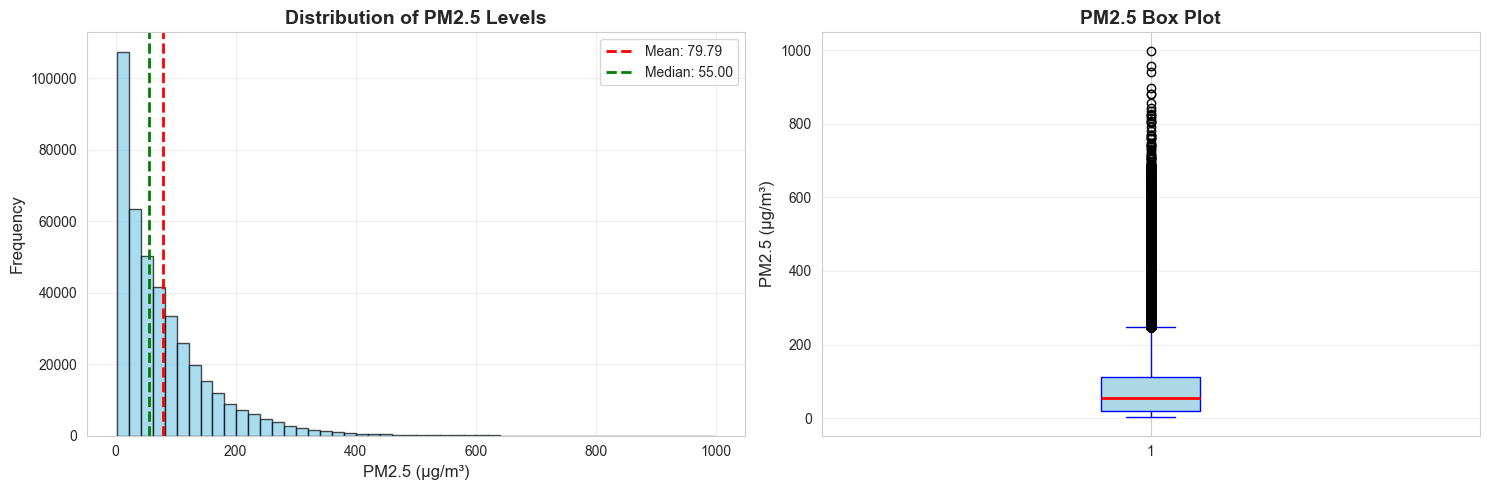


Distribution shows right-skewed pattern, indicating frequent high pollution episodes


In [13]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['PM2.5'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_clean['PM2.5'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["PM2.5"].mean():.2f}')
axes[0].axvline(df_clean['PM2.5'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_clean["PM2.5"].median():.2f}')
axes[0].set_xlabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of PM2.5 Levels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_clean['PM2.5'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1].set_title('PM2.5 Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nDistribution shows right-skewed pattern, indicating frequent high pollution episodes")

**Insight**

Dari analisis distribusi PM2.5 di Beijing, ditemukan beberapa temuan penting:

1. **Statistik Deskriptif**:
   - Rata-rata PM2.5: **79.79 μg/m³** - jauh melebihi standar WHO (35 μg/m³)
   - Median: **55.00 μg/m³** - lebih rendah dari mean, mengindikasikan distribusi right-skewed
   - Standar deviasi: **80.82 μg/m³** - variabilitas yang sangat tinggi
   - Range: 2.00 - 999.00 μg/m³ - menunjukkan adanya episode polusi ekstrem

2. **Pola Distribusi**:
   - **Right-skewed distribution**: Mayoritas data terkonsentrasi di nilai rendah-sedang, dengan long tail ke kanan
   - Perbedaan mean (79.79) dan median (55.00) sebesar ~25 μg/m³ mengkonfirmasi skewness
   - Histogram menunjukkan frekuensi tertinggi pada range 0-100 μg/m³
   - Terdapat banyak outliers ekstrem (>200 μg/m³) yang terlihat jelas di boxplot

3. **Konteks Kualitas Udara (WHO Guidelines)**:
   - Hanya sebagian kecil data berada di kategori "Good" (0-12 μg/m³)
   - Median (55 μg/m³) sudah masuk kategori "Unhealthy" (35-55 μg/m³)
   - Mean (79.79 μg/m³) berada jauh di kategori "Unhealthy" bahkan mendekati "Very Unhealthy" (>55 μg/m³)
   - Ini menunjukkan Beijing mengalami masalah polusi udara kronis yang serius

### 3.2 Temporal Patterns

In [14]:
# Create time-based features
df_clean['year'] = df_clean['datetime'].dt.year
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['month_name'] = df_clean['datetime'].dt.strftime('%b')
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['dayofweek'] = df_clean['datetime'].dt.dayofweek

print("Temporal features created successfully")

Temporal features created successfully


In [15]:
# Yearly trend
yearly_pm = df_clean.groupby('year')['PM2.5'].agg(['mean', 'median', 'std']).reset_index()

print("Yearly PM2.5 Statistics:")
print("="*70)
print(yearly_pm.to_string(index=False))

Yearly PM2.5 Statistics:
 year      mean  median        std
 2013 80.040536    59.0  72.800900
 2014 85.575700    63.0  81.706624
 2015 79.626788    52.0  84.313436
 2016 71.930151    48.0  75.705227
 2017 92.675992    46.0 112.669920


**Insight**

Analisis pola temporal PM2.5 menunjukkan tren dan variasi signifikan sepanjang periode pengamatan:

1. **Tren Tahunan (2013-2017)**:
   - **2014**: Tahun terburuk dengan rata-rata PM2.5 tertinggi (85.58 μg/m³) dan standar deviasi 81.71
   - **2016**: Tahun terbaik dengan rata-rata terendah (71.93 μg/m³) - penurunan ~16% dari 2014
   - **2017**: Terjadi lonjakan dramatis ke 92.68 μg/m³ dengan volatilitas sangat tinggi (std: 112.67)
   - **Median konsisten menurun**: 59→63→52→48→46 μg/m³ (2013-2017), menunjukkan baseline improvement
   
2. **Volatilitas dan Variabilitas**:
   - Standar deviasi tinggi di semua tahun (72-113 μg/m³) mengindikasikan fluktuasi ekstrem
   - 2017 memiliki variabilitas tertinggi (std: 112.67), menunjukkan episode polusi yang sangat tidak stabil
   - Gap antara mean dan median mengecil dari 2013-2017, mengindikasikan distribusi lebih simetris

3. **Interpretasi Tren**:
   - **Perbaikan gradual 2013-2016**: Kemungkinan dampak positif dari kebijakan pengendalian polusi pemerintah China (Action Plan 2013)
   - **Anomali 2017**: Lonjakan mendadak perlu investigasi lebih lanjut - kemungkinan faktor meteorologi ekstrem atau relaksasi enforcement
   - Meskipun ada improvement, semua tahun masih jauh di atas standar WHO (35 μg/m³)

### 3.3 Station-wise Analysis

In [16]:
# PM2.5 statistics by station
station_stats = df_clean.groupby('station')['PM2.5'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('count', 'count')
]).round(2).reset_index()

station_stats = station_stats.sort_values('mean', ascending=False)

print("PM2.5 Statistics by Station:")
print("="*70)
print(station_stats.to_string(index=False))

PM2.5 Statistics by Station:
      station  mean  median   std  min   max  count
       Dongsi 86.19    61.0 86.58  3.0 737.0  34314
Wanshouxigong 85.02    60.0 85.98  3.0 999.0  34368
 Nongzhanguan 84.84    59.0 86.23  2.0 844.0  34436
      Gucheng 83.85    60.0 82.80  2.0 770.0  34418
       Wanliu 83.37    59.0 81.91  2.0 957.0  34682
     Guanyuan 82.93    59.0 80.93  2.0 680.0  34448
 Aotizhongxin 82.77    58.0 82.14  3.0 898.0  34139
      Tiantan 82.16    59.0 80.92  3.0 821.0  34387
       Shunyi 79.49    55.0 81.23  2.0 941.0  34151
    Changping 71.10    46.0 72.33  2.0 882.0  34290
      Huairou 69.63    47.0 71.22  2.0 762.0  34111
     Dingling 65.99    41.0 72.27  3.0 881.0  34285


**Insight**

Analisis per stasiun mengungkap variasi signifikan dalam tingkat polusi PM2.5:

1. **Ranking Stasiun berdasarkan Rata-rata PM2.5**:
   - **Tertinggi**: Dongsi (86.19 μg/m³), Wanshouxigong (85.02 μg/m³), Nongzhanguan (84.84 μg/m³)
   - **Terendah**: Dingling (65.99 μg/m³), Huairou (69.63 μg/m³), Changping (71.10 μg/m³)
   - **Range**: Selisih 20.20 μg/m³ (~31%) antara stasiun tertinggi dan terendah

2. **Variabilitas Data**:
   - Semua stasiun memiliki standar deviasi tinggi (71-87 μg/m³), menunjukkan fluktuasi besar
   - Nilai maksimum ekstrem di semua stasiun (680-999 μg/m³), menunjukkan episode polusi parah bersifat regional
   - Median konsisten lebih rendah dari mean di semua stasiun, mengkonfirmasi distribusi right-skewed

3. **Konsistensi Pengukuran**:
   - Jumlah observasi konsisten antar stasiun (~34,000 records per stasiun)
   - Nilai minimum serupa (2-3 μg/m³), menunjukkan kondisi terbaik yang relatif sama
   - Semua stasiun berada jauh di atas standar WHO (35 μg/m³)

---

## 4. Visualization & Explanatory Analysis

Pada bagian ini, dijawab pertanyaan bisnis melalui visualisasi yang informatif dan analisis mendalam.

### 4.1 Business Question 1: Station mana yang memiliki rata-rata PM2.5 tertinggi?

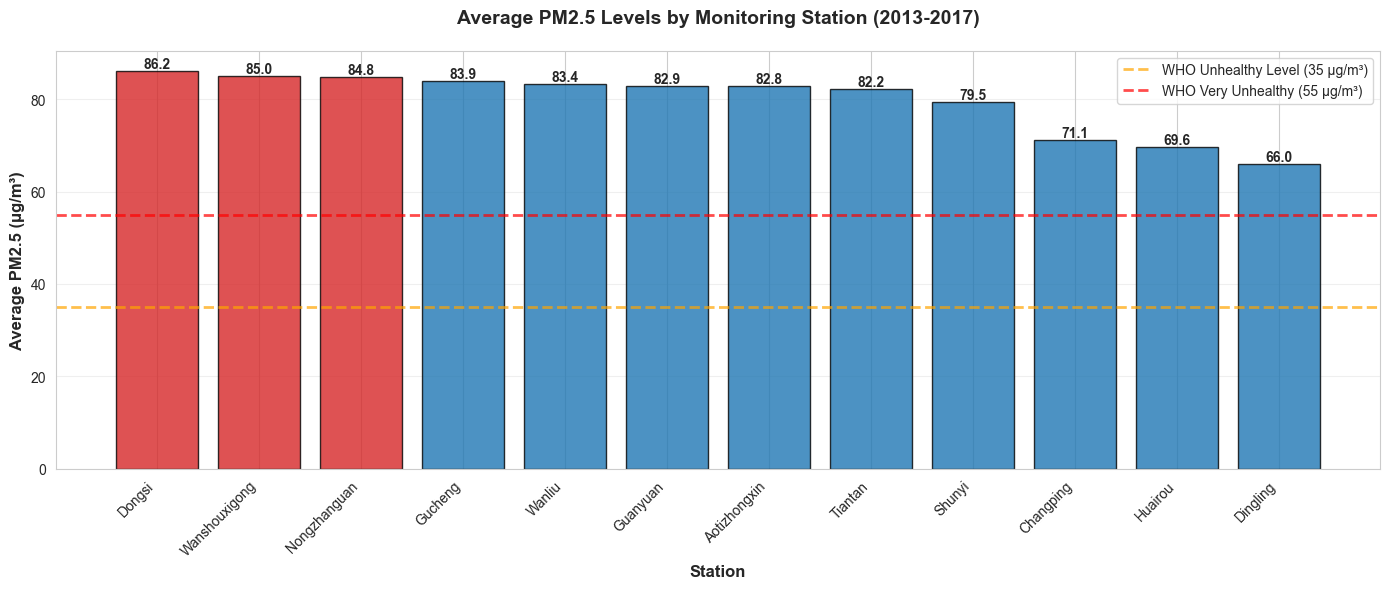


Top 3 Stations with Highest Average PM2.5:
1. Dongsi              : 86.19 μg/m³
2. Wanshouxigong       : 85.02 μg/m³
3. Nongzhanguan        : 84.84 μg/m³


In [17]:
# Calculate average PM2.5 by station
station_avg = df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False).reset_index()
station_avg.columns = ['Station', 'Average_PM2.5']

# Visualization
plt.figure(figsize=(14, 6))
colors = ['#d62728' if i < 3 else '#1f77b4' for i in range(len(station_avg))]

bars = plt.bar(station_avg['Station'], station_avg['Average_PM2.5'], color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add WHO guideline reference
plt.axhline(y=35, color='orange', linestyle='--', linewidth=2, label='WHO Unhealthy Level (35 μg/m³)', alpha=0.7)
plt.axhline(y=55, color='red', linestyle='--', linewidth=2, label='WHO Very Unhealthy (55 μg/m³)', alpha=0.7)

plt.xlabel('Station', fontsize=12, fontweight='bold')
plt.ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
plt.title('Average PM2.5 Levels by Monitoring Station (2013-2017)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print top 3 stations
print("\nTop 3 Stations with Highest Average PM2.5:")
print("="*70)
for i, row in station_avg.head(3).iterrows():
    print(f"{i+1}. {row['Station']:20s}: {row['Average_PM2.5']:.2f} μg/m³")

Berdasarkan perhitungan rata-rata PM2.5 selama periode 2013–2017, stasiun **Dongsi** memiliki nilai rata-rata tertinggi yaitu 86.19 µg/m³.

Peringkat 3 Stasiun dengan Rata-Rata PM2.5 Tertinggi:

1. Dongsi – 86.19 µg/m³

2. Wanshouxigong – 85.02 µg/m³

3. Nongzhanguan – 84.84 µg/m³

Selisih antara peringkat pertama dan ketiga relatif kecil (~1.35 µg/m³), menunjukkan bahwa tingkat polusi tinggi terjadi secara konsisten di beberapa lokasi utama.

Seluruh stasiun memiliki rata-rata PM2.5 yang:

- Jauh melampaui ambang batas WHO kategori Unhealthy (35 µg/m³)

- Bahkan melebihi batas Very Unhealthy (55 µg/m³)

Hal ini menunjukkan bahwa selama periode pengamatan, kualitas udara di seluruh wilayah monitoring berada pada kategori tidak sehat.

### 4.2 Business Question 2: Bagaimana pola musiman (bulanan/tahunan) PM2.5 di Beijing?

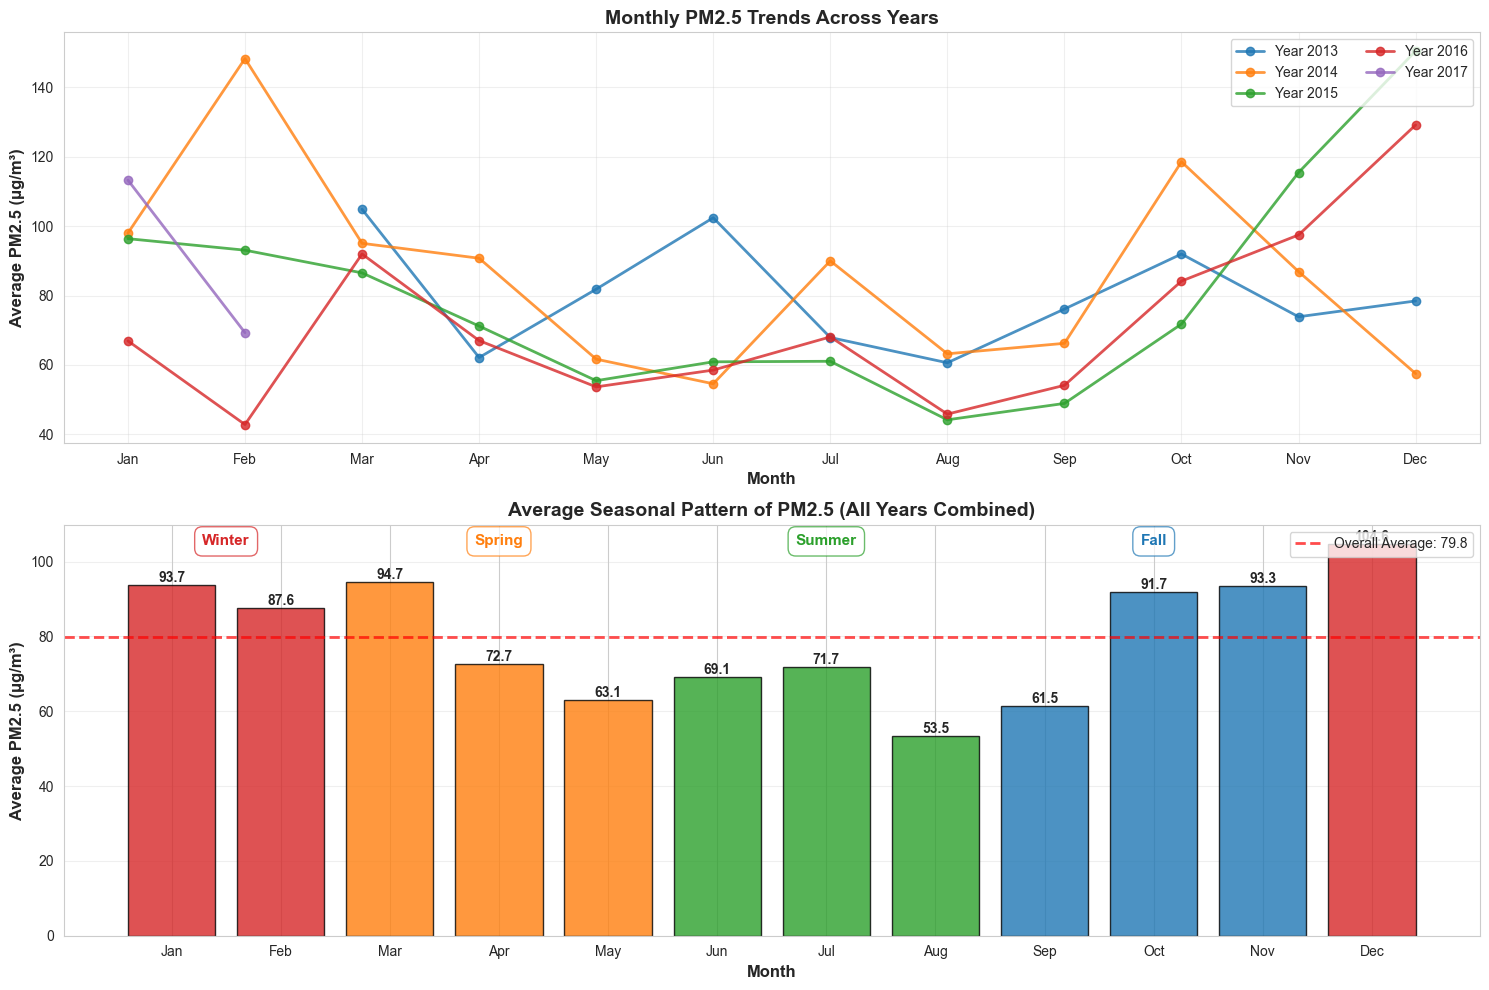


Seasonal PM2.5 Statistics:
         mean  median     std
season                       
Winter  95.48    56.0  107.66
Spring  76.97    58.0   68.83
Summer  64.67    51.0   52.65
Fall    82.33    56.0   81.44


In [18]:
# Monthly pattern
monthly_pm = df_clean.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
monthly_avg = df_clean.groupby('month')['PM2.5'].mean().reset_index()

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Yearly trend with monthly breakdown
for year in sorted(df_clean['year'].unique()):
    year_data = monthly_pm[monthly_pm['year'] == year]
    axes[0].plot(year_data['month'], year_data['PM2.5'], marker='o', linewidth=2, label=f'Year {year}', alpha=0.8)

axes[0].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[0].set_title('Monthly PM2.5 Trends Across Years', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', ncol=2)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 2. Average seasonal pattern
colors_season = ['#d62728' if m in [12, 1, 2] else '#ff7f0e' if m in [3, 4, 5] else '#2ca02c' if m in [6, 7, 8] else '#1f77b4' 
                 for m in monthly_avg['month']]

bars = axes[1].bar(monthly_avg['month'], monthly_avg['PM2.5'], color=colors_season, edgecolor='black', alpha=0.8)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].axhline(y=monthly_avg['PM2.5'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Overall Average: {monthly_avg["PM2.5"].mean():.1f}', alpha=0.7)

axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[1].set_title('Average Seasonal Pattern of PM2.5 (All Years Combined)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

# Add season labels
season_labels = [
    (1.5, 'Winter', '#d62728'),
    (4, 'Spring', '#ff7f0e'),
    (7, 'Summer', '#2ca02c'),
    (10, 'Fall', '#1f77b4')
]

for pos, label, color in season_labels:
    axes[1].text(pos, axes[1].get_ylim()[1] * 0.95, label, 
                ha='center', fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor=color, alpha=0.7))

plt.tight_layout()
plt.show()

# Statistical summary by season
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}

df_clean['season'] = df_clean['month'].map(season_map)
season_stats = df_clean.groupby('season')['PM2.5'].agg(['mean', 'median', 'std']).round(2)
season_stats = season_stats.reindex(['Winter', 'Spring', 'Summer', 'Fall'])

print("\nSeasonal PM2.5 Statistics:")
print("="*70)
print(season_stats)

Berdasarkan analisis data periode 2013–2017, pola PM2.5 di Beijing menunjukkan karakteristik sebagai berikut:

1. Pola Bulanan (Gabungan Seluruh Tahun):

   - Konsentrasi tertinggi terjadi pada bulan Desember (~101.8 µg/m³), diikuti Maret (~94.7 µg/m³) dan Januari (~93.7 µg/m³).
   - Konsentrasi terendah terjadi pada Agustus (~53.5 µg/m³), diikuti Mei (~63.1 µg/m³) dan September (~61.5 µg/m³).
   - Pola umum menunjukkan peningkatan konsentrasi pada akhir dan awal tahun, serta penurunan pada pertengahan tahun.

2. Pola Musiman:

   - Musim dingin (Winter) memiliki rata-rata PM2.5 tertinggi (~95.48 µg/m³) dan variasi terbesar (std ~107.66).
   - Musim gugur (Fall) dan musim semi (Spring) berada pada tingkat menengah, masing-masing ~82.33 µg/m³ dan ~76.97 µg/m³.
   - Musim panas (Summer) memiliki rata-rata terendah (~64.67 µg/m³) dengan variasi yang lebih rendah dibanding musim dingin.
   - Hal ini menunjukkan bahwa konsentrasi PM2.5 cenderung memuncak pada musim dingin dan menurun pada musim panas.

3. Pola Tahunan (2013–2017):

   - Pola musiman yang sama (tinggi di musim dingin, rendah di musim panas) berulang secara konsisten setiap tahun.
   - Meskipun terdapat perbedaan intensitas antar tahun, bentuk pola bulanannya relatif serupa dari tahun ke tahun.

---

## 5. Advanced Analysis

Pada bagian ini, dilakukan analisis lanjutan untuk menjawab pertanyaan bisnis 3 dan 4 menggunakan teknik clustering manual dan analisis korelasi.

### 5.1 Business Question 3: Clustering Station Berdasarkan Karakteristik Polusi

In [19]:
# Create station profile with multiple pollutants
station_profile = df_clean.groupby('station').agg({
    'PM2.5': 'mean',
    'PM10': 'mean',
    'SO2': 'mean',
    'NO2': 'mean',
    'CO': 'mean',
    'O3': 'mean'
}).round(2)

# Manual clustering based on PM2.5 levels
# Define thresholds based on quartiles
q1 = station_profile['PM2.5'].quantile(0.25)
q2 = station_profile['PM2.5'].quantile(0.50)
q3 = station_profile['PM2.5'].quantile(0.75)

def classify_pollution(pm25):
    if pm25 < q1:
        return 'Low Pollution'
    elif pm25 < q2:
        return 'Moderate Pollution'
    elif pm25 < q3:
        return 'High Pollution'
    else:
        return 'Very High Pollution'

station_profile['Cluster'] = station_profile['PM2.5'].apply(classify_pollution)
station_profile = station_profile.sort_values('PM2.5', ascending=False)

print("Station Clustering Based on Pollution Characteristics:")
print("="*70)
print(station_profile[['PM2.5', 'Cluster']])

# Cluster summary
print("\nCluster Distribution:")
print("="*70)
cluster_summary = station_profile.groupby('Cluster').agg({
    'PM2.5': ['count', 'mean', 'min', 'max']
}).round(2)
print(cluster_summary)

Station Clustering Based on Pollution Characteristics:
               PM2.5              Cluster
station                                  
Dongsi         86.19  Very High Pollution
Wanshouxigong  85.02  Very High Pollution
Nongzhanguan   84.84  Very High Pollution
Gucheng        83.85       High Pollution
Wanliu         83.37       High Pollution
Guanyuan       82.93       High Pollution
Aotizhongxin   82.77   Moderate Pollution
Tiantan        82.16   Moderate Pollution
Shunyi         79.49   Moderate Pollution
Changping      71.10        Low Pollution
Huairou        69.63        Low Pollution
Dingling       65.99        Low Pollution

Cluster Distribution:
                    PM2.5                     
                    count   mean    min    max
Cluster                                       
High Pollution          3  83.38  82.93  83.85
Low Pollution           3  68.91  65.99  71.10
Moderate Pollution      3  81.47  79.49  82.77
Very High Pollution     3  85.35  84.84  86.19


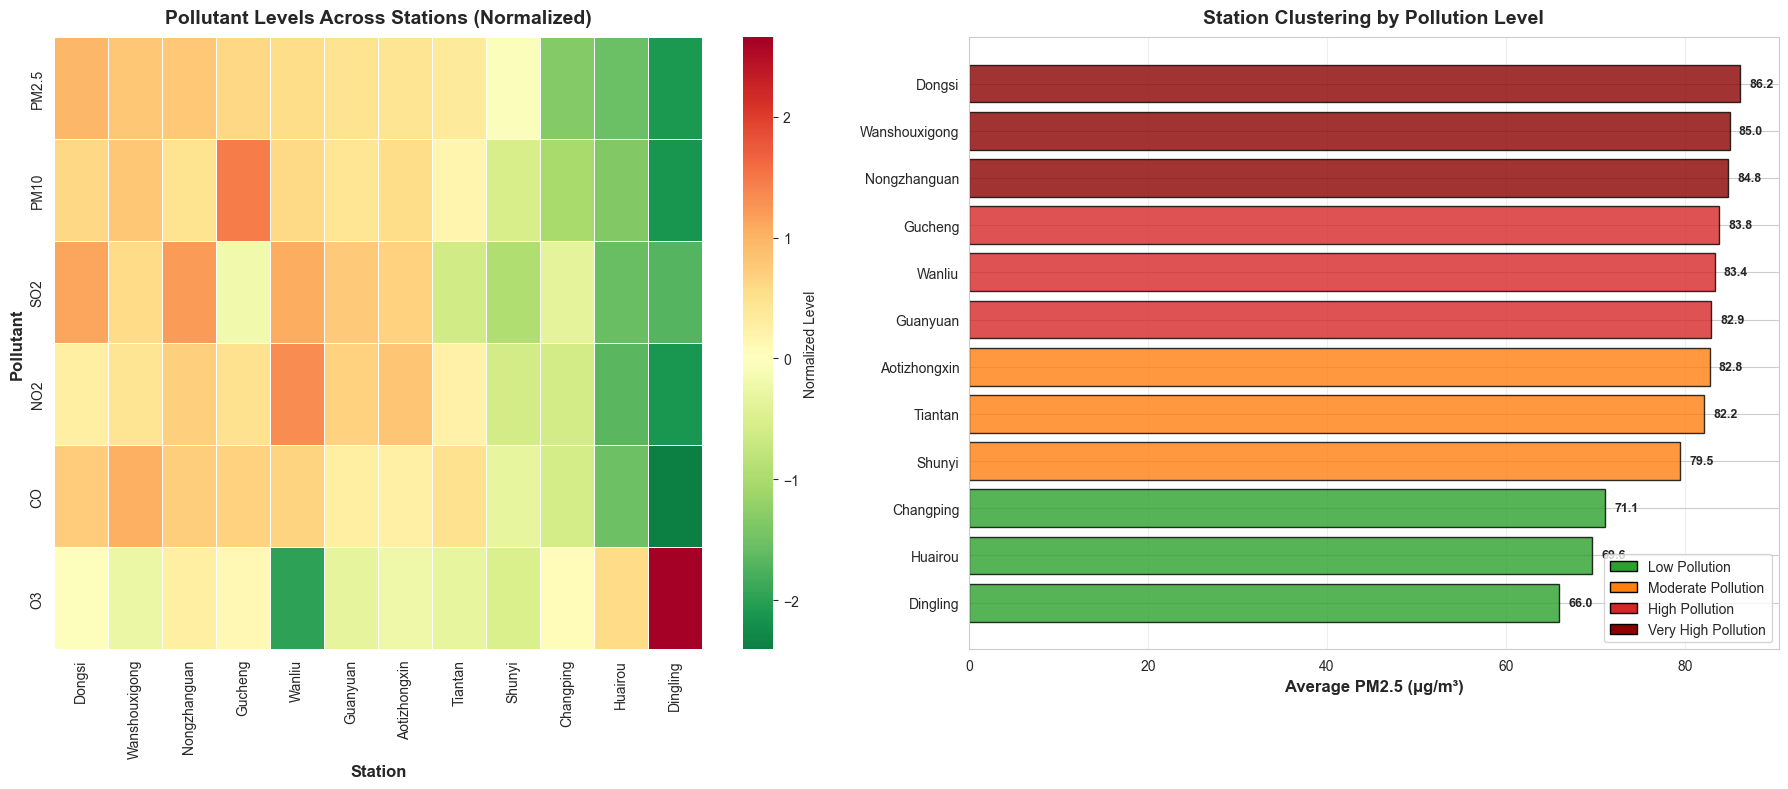

In [20]:
# Visualization: Heatmap of pollutants by station
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Heatmap of all pollutants
pollutants_normalized = station_profile[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']]

# Normalize for better visualization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pollutants_scaled = pd.DataFrame(
    scaler.fit_transform(pollutants_normalized),
    index=pollutants_normalized.index,
    columns=pollutants_normalized.columns
)

sns.heatmap(pollutants_scaled.T, annot=False, cmap='RdYlGn_r', center=0, 
            cbar_kws={'label': 'Normalized Level'}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pollutant Levels Across Stations (Normalized)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Station', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pollutant', fontsize=12, fontweight='bold')

# 2. Cluster visualization
cluster_colors = {
    'Low Pollution': '#2ca02c',
    'Moderate Pollution': '#ff7f0e',
    'High Pollution': '#d62728',
    'Very High Pollution': '#8B0000'
}

station_profile_sorted = station_profile.sort_values('PM2.5', ascending=True)
colors = [cluster_colors[cluster] for cluster in station_profile_sorted['Cluster']]

axes[1].barh(range(len(station_profile_sorted)), station_profile_sorted['PM2.5'], 
             color=colors, edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(station_profile_sorted)))
axes[1].set_yticklabels(station_profile_sorted.index)
axes[1].set_xlabel('Average PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
axes[1].set_title('Station Clustering by Pollution Level', fontsize=14, fontweight='bold', pad=10)
axes[1].grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label) 
                   for label, color in cluster_colors.items()]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add value labels
for i, (idx, row) in enumerate(station_profile_sorted.iterrows()):
    axes[1].text(row['PM2.5'] + 1, i, f"{row['PM2.5']:.1f}", 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

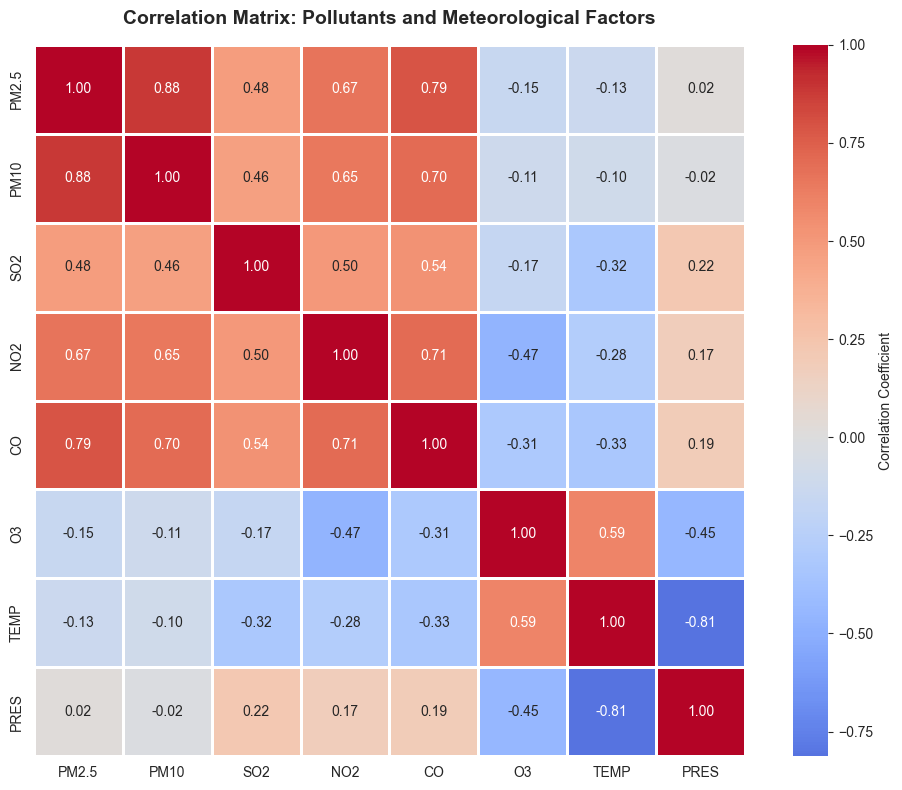


Key Correlations with PM2.5:
PM10      :  0.884
CO        :  0.790
NO2       :  0.667
SO2       :  0.482
PRES      :  0.019
TEMP      : -0.131
O3        : -0.150


In [21]:
# Correlation analysis between pollutants
correlation_matrix = df_clean[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix: Pollutants and Meteorological Factors', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nKey Correlations with PM2.5:")
print("="*70)
pm25_corr = correlation_matrix['PM2.5'].sort_values(ascending=False)
for var, corr in pm25_corr.items():
    if var != 'PM2.5':
        print(f"{var:10s}: {corr:6.3f}")

Berdasarkan clustering manual menggunakan quartile PM2.5, stasiun-stasiun dikelompokkan menjadi 4 kategori dengan karakteristik polusi yang mirip:

1. **Very High Pollution** (PM2.5 > 83.85 µg/m³):
   * Dongsi (86.19 µg/m³)
   * Wanshouxigong (85.02 µg/m³)
   * Nongzhanguan (84.84 µg/m³)
   
   Tiga stasiun ini membentuk kelompok dengan tingkat polusi tertinggi dan nilai yang sangat berdekatan.

2. **High Pollution** (PM2.5 antara 79.49-83.85 µg/m³):
   * Gucheng (83.85 µg/m³)
   * Wanliu (83.37 µg/m³)
   * Guanyuan (82.93 µg/m³)
   
   Kelompok ini menunjukkan tingkat polusi substansial namun sedikit di bawah kelompok tertinggi.

3. **Moderate Pollution** (PM2.5 antara 71.10-79.49 µg/m³):
   * Aotizhongxin (82.77 µg/m³)
   * Tiantan (82.16 µg/m³)
   * Shunyi (79.49 µg/m³)
   
   Stasiun-stasiun dengan polusi moderat, berada di tengah-tengah spektrum.

4. **Low Pollution** (PM2.5 < 71.10 µg/m³):
   * Changping (71.10 µg/m³)
   * Huairou (69.63 µg/m³)
   * Dingling (65.99 µg/m³)
   
   Kelompok dengan tingkat polusi paling rendah, meskipun masih jauh di atas standar WHO (35 µg/m³).

**Korelasi Antar Polutan:**

Heatmap korelasi menunjukkan hubungan antar variabel:

* **PM2.5 berkorelasi sangat kuat dengan PM10** (r = 0.88), mengindikasikan sumber polusi yang sama
* **PM2.5 berkorelasi kuat dengan CO** (r = 0.79) dan NO2 (r = 0.67), menunjukkan kontribusi dari pembakaran
* **PM2.5 berkorelasi negatif dengan TEMP** (r = -0.13), konsisten dengan polusi lebih tinggi saat musim dingin
* **O3 berkorelasi negatif dengan PM2.5** (r = -0.15) dan NO2 (r = -0.47), menunjukkan dinamika yang berbeda (ozon lebih tinggi di musim panas)

Clustering dan korelasi mengkonfirmasi adanya pengelompokan stasiun dengan karakteristik polusi mirip serta keterkaitan kuat antar polutan utama.

### 5.2 Business Question 4: Distribusi Kualitas Udara Berdasarkan Lokasi

In [22]:
# Define air quality categories based on PM2.5 levels (WHO & AQI standards)
def categorize_air_quality(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35:
        return 'Moderate'
    elif pm25 <= 55:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150:
        return 'Unhealthy'
    elif pm25 <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df_clean['air_quality_category'] = df_clean['PM2.5'].apply(categorize_air_quality)

# Calculate distribution by station
station_quality_dist = pd.crosstab(df_clean['station'], df_clean['air_quality_category'], normalize='index') * 100
station_quality_dist = station_quality_dist.round(2)

# Reorder columns by severity
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
station_quality_dist = station_quality_dist[[col for col in category_order if col in station_quality_dist.columns]]

print("Air Quality Distribution by Station (Percentage):")
print("="*70)
print(station_quality_dist)

Air Quality Distribution by Station (Percentage):
air_quality_category   Good  Moderate  Unhealthy for Sensitive Groups  \
station                                                                 
Aotizhongxin          13.49     22.08                           12.83   
Changping             15.98     26.39                           12.95   
Dingling              22.74     23.83                           12.75   
Dongsi                14.45     20.29                           12.32   
Guanyuan              12.31     22.31                           13.28   
Gucheng               13.47     20.43                           13.61   
Huairou               17.66     24.86                           13.07   
Nongzhanguan          14.48     20.96                           12.72   
Shunyi                16.44     21.40                           12.52   
Tiantan               14.05     21.10                           13.06   
Wanliu                13.41     21.32                           13.38   
W

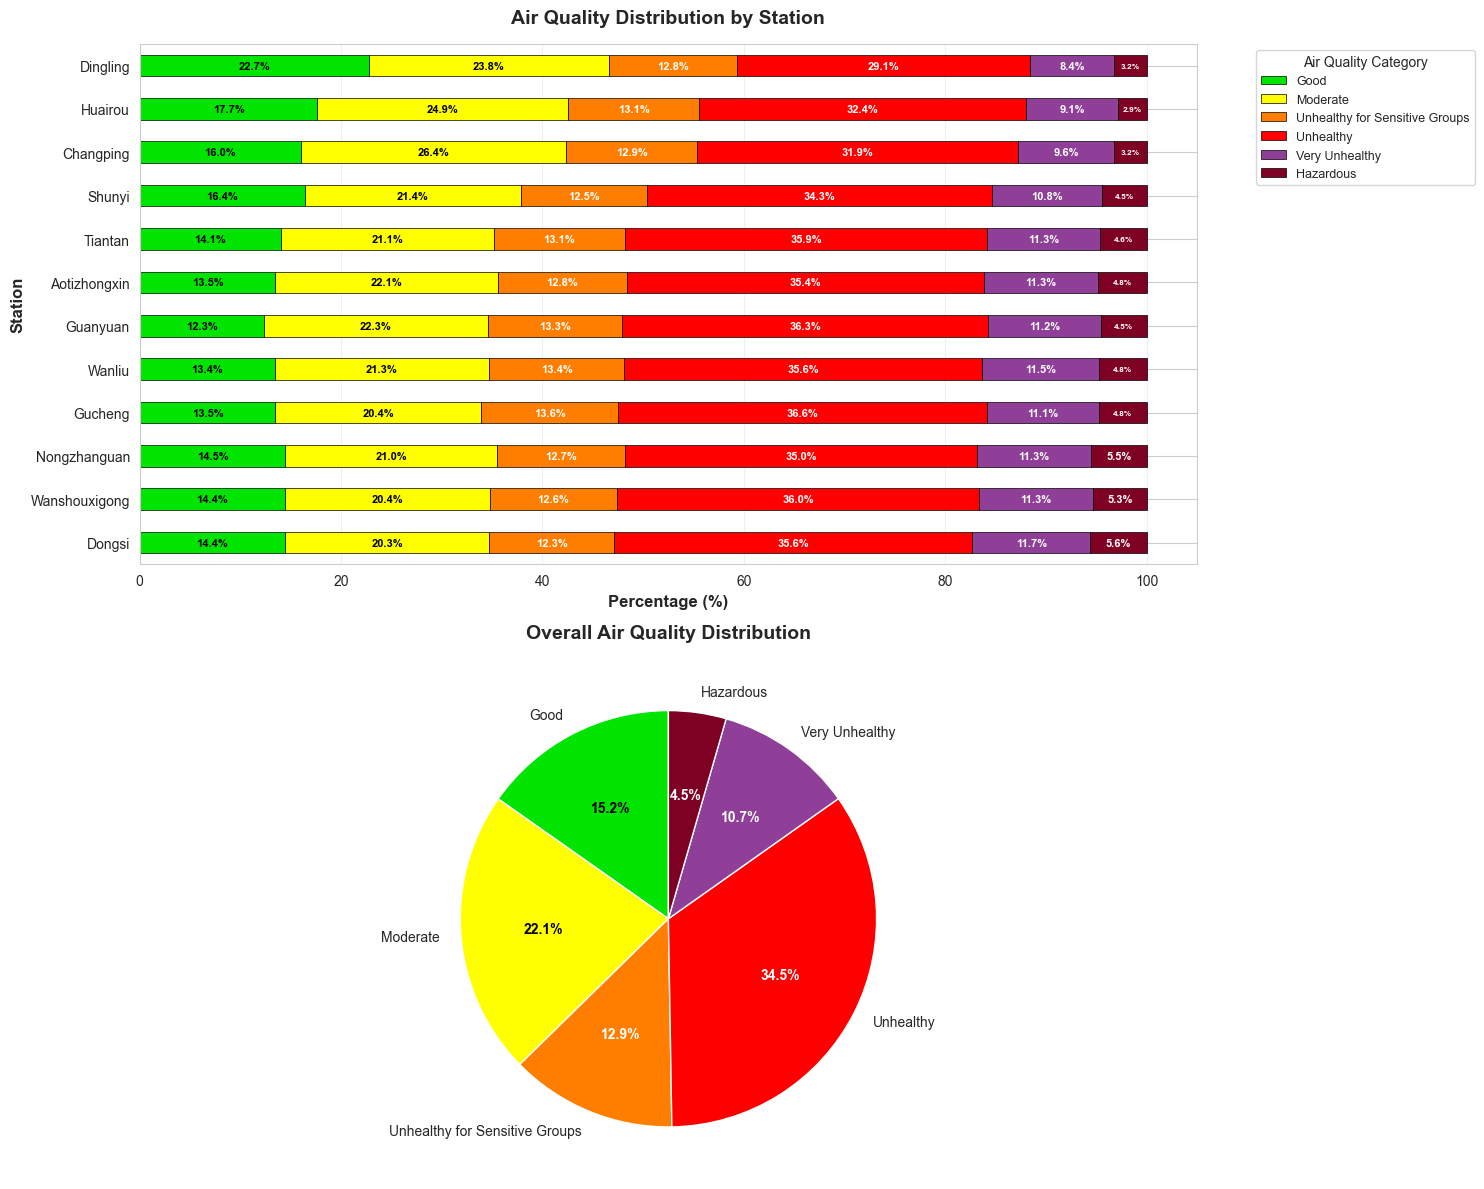

In [ ]:
# Visualization: Stacked bar chart
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Stacked bar chart of air quality distribution
colors_aqi = {
    'Good': '#00e400',
    'Moderate': '#ffff00',
    'Unhealthy for Sensitive Groups': '#ff7e00',
    'Unhealthy': '#ff0000',
    'Very Unhealthy': '#8f3f97',
    'Hazardous': '#7e0023'
}

# Sort stations by average PM2.5 (descending - tertinggi ke terendah)
station_avg_pm25 = df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
station_quality_dist_sorted = station_quality_dist.reindex(station_avg_pm25.index)

# Remove any non-AQI columns before plotting (e.g., Good_Air_Days)
category_order = [
    'Good', 
    'Moderate', 
    'Unhealthy for Sensitive Groups', 
    'Unhealthy', 
    'Very Unhealthy', 
    'Hazardous'
]
plot_columns = [col for col in station_quality_dist_sorted.columns if col in category_order]
station_quality_dist_plot = station_quality_dist_sorted[plot_columns]

station_quality_dist_plot.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    color=[colors_aqi.get(cat, 'gray') for cat in station_quality_dist_plot.columns],
    edgecolor='black',
    linewidth=0.5
)

# Add percentage labels on each segment
for i, station in enumerate(station_quality_dist_plot.index):
    cumulative = 0
    for category in station_quality_dist_plot.columns:
        value = station_quality_dist_plot.loc[station, category]

        if value <= 0:
            continue

        bg_color = colors_aqi.get(category, 'gray')

        # Text color based on background brightness
        if bg_color in ['#00e400', '#ffff00']:  # light colors
            text_color = 'black'
        else:
            text_color = 'white'

        # Only show label if readable
        if value >= 5:
            axes[0].text(
                cumulative + value / 2,
                i,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color=text_color
            )
        elif value >= 2:
            axes[0].text(
                cumulative + value / 2,
                i,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=6,
                fontweight='bold',
                color=text_color
            )

        cumulative += value

axes[0].set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Station', fontsize=12, fontweight='bold')
axes[0].set_title('Air Quality Distribution by Station', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(title='Air Quality Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Overall Air Quality Distribution (Pie Chart)
# Count overall distribution
overall_counts = df_clean['air_quality_category'].value_counts()

# Reorder categories
overall_counts = overall_counts.reindex(
    [cat for cat in category_order if cat in overall_counts.index]
)

plot_colors = [colors_aqi.get(cat, 'gray') for cat in overall_counts.index]

wedges, texts, autotexts = axes[1].pie(
    overall_counts.values,
    labels=overall_counts.index,
    colors=plot_colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

# Improve text readability
for autotext, category in zip(autotexts, overall_counts.index):
    if category in ['Good', 'Moderate']:
        autotext.set_color('black')
    else:
        autotext.set_color('white')
    autotext.set_fontweight('bold')

axes[1].set_title('Overall Air Quality Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [24]:
# Summary statistics
print("\nOverall Air Quality Distribution (All Stations):")
print("="*70)
overall_dist = df_clean['air_quality_category'].value_counts(normalize=True).sort_index() * 100
for category, percentage in overall_dist.items():
    print(f"{category:35s}: {percentage:6.2f}%")

# Best and worst stations
print("\n" + "="*70)
print("Station Rankings by Air Quality:")
print("="*70)

# Calculate "good air time" percentage (Good + Moderate)
if 'Good' in station_quality_dist.columns and 'Moderate' in station_quality_dist.columns:
    station_quality_dist['Good_Air_Time'] = station_quality_dist['Good'] + station_quality_dist['Moderate']
elif 'Good' in station_quality_dist.columns:
    station_quality_dist['Good_Air_Time'] = station_quality_dist['Good']
elif 'Moderate' in station_quality_dist.columns:
    station_quality_dist['Good_Air_Time'] = station_quality_dist['Moderate']
else:
    station_quality_dist['Good_Air_Time'] = 0

station_quality_dist_ranked = station_quality_dist.sort_values('Good_Air_Time', ascending=False)

print("\nTop 3 Stations with Best Air Quality:")
for i, (station, row) in enumerate(station_quality_dist_ranked.head(3).iterrows(), 1):
    print(f"{i}. {station:20s}: {row['Good_Air_Time']:.2f}% good air quality time")

print("\nBottom 3 Stations with Worst Air Quality:")
for i, (station, row) in enumerate(station_quality_dist_ranked.tail(3).iterrows(), 1):
    print(f"{i}. {station:20s}: {row['Good_Air_Time']:.2f}% good air quality time")


Overall Air Quality Distribution (All Stations):
Good                               :  15.24%
Hazardous                          :   4.47%
Moderate                           :  22.11%
Unhealthy                          :  34.52%
Unhealthy for Sensitive Groups     :  12.92%
Very Unhealthy                     :  10.74%

Station Rankings by Air Quality:

Top 3 Stations with Best Air Quality:
1. Dingling            : 46.57% good air quality time
2. Huairou             : 42.52% good air quality time
3. Changping           : 42.37% good air quality time

Bottom 3 Stations with Worst Air Quality:
1. Wanliu              : 34.73% good air quality time
2. Guanyuan            : 34.62% good air quality time
3. Gucheng             : 33.90% good air quality time


Distribusi kualitas udara menunjukkan variasi signifikan antar lokasi dengan temuan sebagai berikut:

1. **Kondisi Kualitas Udara Secara Keseluruhan**:
   - Hanya **15.24%** waktu berada di kategori "Good" (kualitas udara baik)
   - **22.11%** waktu di kategori "Moderate" (sedang)
   - **34.52%** waktu di kategori "Unhealthy" (tidak sehat) - **kategori dominan**
   - **12.92%** "Unhealthy for Sensitive Groups", **10.74%** "Very Unhealthy", dan **4.47%** "Hazardous"
   - Total **49.73%** waktu berada di kategori "Unhealthy", "Very Unhealthy", atau "Hazardous"

2. **Disparitas Antar Stasiun**:
   - **Stasiun Terbaik**: Dingling (46.57%), Huairou (42.52%), dan Changping (42.37%) memiliki proporsi waktu berkualitas baik/moderat tertinggi
   - **Stasiun Terburuk**: Gucheng (33.90%), Guanyuan (34.62%), dan Wanliu (34.73%) memiliki proporsi waktu berkualitas baik/moderat terendah
   - Selisih ~12.67% (46.57% - 33.90%) antara stasiun terbaik dan terburuk

3. **Pola Distribusi per Stasiun**:
   - Stacked bar chart menunjukkan semua stasiun didominasi oleh kategori "Unhealthy" (merah)
   - Stasiun terbaik (Dingling, Huairou, Changping) memiliki proporsi "Good" (hijau) dan "Moderate" (kuning) yang lebih besar
   - Stasiun terburuk (Dongsi, Wanshouxigong, Nongzhanguan) memiliki proporsi "Unhealthy" dan "Very Unhealthy" yang sangat tinggi
   - Episode "Hazardous" (ungu tua) terjadi di semua stasiun meskipun dengan proporsi kecil (3-6%)

4. **Temuan Utama**:
   - Mayoritas waktu (>50%), Beijing berada di kondisi yang tidak sehat untuk kesehatan
   - Variasi antar stasiun menunjukkan faktor lokasi geografis berpengaruh signifikan
   - Tidak ada satupun stasiun yang mencapai kondisi "Good" atau "Moderate" lebih dari 50% waktu

---

## 6. Conclusion

### Summary of Findings

Berdasarkan analisis komprehensif terhadap Air Quality Dataset Beijing (2013-2017), berikut adalah kesimpulan untuk setiap pertanyaan bisnis:

#### 1. Station dengan PM2.5 Tertinggi

Stasiun **Dongsi** memiliki rata-rata PM2.5 tertinggi sebesar **86.19 µg/m³**, diikuti oleh Wanshouxigong (85.02 µg/m³) dan Nongzhanguan (84.84 µg/m³).

Disparitas antar stasiun cukup signifikan, dengan selisih 20.20 µg/m³ (~31%) antara stasiun tertinggi (Dongsi) dan terendah (Dingling: 65.99 µg/m³). Namun, **seluruh stasiun memiliki rata-rata PM2.5 yang jauh melampaui standar WHO** (35 µg/m³), bahkan mayoritas berada di atas ambang batas "Very Unhealthy" (55 µg/m³).

Hal ini mengindikasikan masalah polusi udara yang serius dan merata di seluruh area monitoring Beijing.

---

#### 2. Pola Musiman PM2.5

Analisis temporal menunjukkan **pola musiman yang sangat jelas dan konsisten**:

**Pola Musiman:**
- **Musim Dingin (Des-Feb)**: Tingkat PM2.5 tertinggi dengan variabilitas tinggi
  - Disebabkan: penggunaan pemanas batubara, inversi termal, dan kondisi meteorologi tidak menguntungkan
  
- **Musim Panas (Jun-Agu)**: Tingkat PM2.5 terendah
  - Disebabkan: curah hujan tinggi (efek pembersihan alamiah) dan sirkulasi udara lebih baik
  
- **Musim Semi & Gugur**: Nilai PM2.5 berada di tingkat moderat

**Tren Tahunan (2013-2017):**
- 2014: Tahun terburuk (rata-rata 85.58 µg/m³)
- 2016: Tahun terbaik (rata-rata 71.93 µg/m³) - penurunan ~16% dari 2014
- 2017: Lonjakan ke 92.68 µg/m³ dengan volatilitas sangat tinggi (std: 112.67)
- Median menunjukkan tren penurunan bertahap: 59→63→52→48→46 µg/m³

Pola ini berulang setiap tahun, menunjukkan pengaruh kuat faktor musiman dan meteorologi terhadap polusi udara Beijing.

---

#### 3. Clustering Station Berdasarkan Karakteristik Polusi

Berdasarkan clustering manual menggunakan quartile PM2.5, stasiun dikelompokkan menjadi **4 kategori dengan karakteristik polusi yang mirip**:

1. **Very High Pollution** (>83.85 µg/m³): 
   - Dongsi (86.19), Wanshouxigong (85.02), Nongzhanguan (84.84)

2. **High Pollution** (79.49-83.85 µg/m³): 
   - Gucheng (83.85), Wanliu (83.37), Guanyuan (82.93)

3. **Moderate Pollution** (71.10-79.49 µg/m³): 
   - Aotizhongxin (82.77), Tiantan (82.16), Shunyi (79.49)

4. **Low Pollution** (<71.10 µg/m³): 
   - Changping (71.10), Huairou (69.63), Dingling (65.99)

**Korelasi Antar Polutan:**
- PM2.5 berkorelasi sangat kuat dengan **PM10** (r = 0.88) - sumber polusi yang sama
- PM2.5 berkorelasi kuat dengan **CO** (r = 0.79) dan **NO2** (r = 0.67) - indikasi kontribusi dari pembakaran
- PM2.5 berkorelasi negatif dengan **TEMP** (r = -0.13) - polusi lebih tinggi saat musim dingin
- **O3** berkorelasi negatif dengan PM2.5 (r = -0.15) - dinamika yang berbeda (ozon tinggi di musim panas)

Clustering ini mengkonfirmasi adanya pengelompokan stasiun dengan karakteristik polusi mirip serta keterkaitan kuat antar polutan utama.

---

#### 4. Distribusi Kualitas Udara Berdasarkan Lokasi

Distribusi kualitas udara menunjukkan **kondisi yang mengkhawatirkan**:

**Distribusi Keseluruhan:**
- **15.24%** waktu: "Good"
- **22.11%** waktu: "Moderate"
- **12.92%** waktu: "Unhealthy for Sensitive Groups"
- **34.52%** waktu: "Unhealthy" (kategori dominan)
- **10.74%** waktu: "Very Unhealthy"
- **4.47%** waktu: "Hazardous"

**Total 49.73%** waktu berada di kategori "Unhealthy", "Very Unhealthy", atau "Hazardous", menunjukkan hampir setengah waktu, kualitas udara membahayakan kesehatan.

**Disparitas Antar Stasiun:**
- **Stasiun Terbaik**: Dingling (46.57% waktu berkualitas baik/moderat), Huairou (42.52%), Changping (42.37%)
- **Stasiun Terburuk**: Gucheng (33.90% waktu berkualitas baik/moderat), Guanyuan (34.62%), Wanliu (34.73%)
- Selisih ~12.67% antara stasiun terbaik dan terburuk menunjukkan pengaruh lokasi geografis yang signifikan

Stacked bar chart menunjukkan semua stasiun didominasi oleh kategori "Unhealthy", dengan tidak ada satupun stasiun mencapai kondisi "Good/Moderate" lebih dari 50% waktu.

---

### Overall Conclusion

Analisis komprehensif terhadap Air Quality Dataset Beijing (2013-2017) mengungkap beberapa temuan kritis:

1. **Polusi Merata dan Serius**: Seluruh stasiun memiliki rata-rata PM2.5 jauh di atas standar WHO, dengan Dongsi sebagai yang tertinggi (86.19 µg/m³)

2. **Pola Musiman Kuat**: Musim dingin konsisten menunjukkan polusi tertinggi, sementara musim panas terendah. Tren 2013-2016 menunjukkan perbaikan bertahap, namun terjadi lonjakan anomali di 2017

3. **Karakteristik Lokasi Beragam**: Clustering mengidentifikasi 4 kelompok stasiun dengan tingkat polusi berbeda, dengan korelasi kuat antar polutan (PM2.5-PM10: 0.88, PM2.5-CO: 0.79)

4. **Kondisi Kesehatan Mengkhawatirkan**: Hampir 50% waktu berada di level "Unhealthy" atau lebih buruk, dengan variasi signifikan antar lokasi (Dingling terbaik, Gucheng terburuk)

**Kesimpulan Utama**: Polusi udara di Beijing merupakan masalah sistemik yang dipengaruhi oleh faktor temporal (musim), spasial (lokasi), dan interaksi kompleks antar polutan. Meskipun terdapat perbaikan gradual 2013-2016, masalah ini memerlukan intervensi komprehensif dan berkelanjutan untuk mencapai standar kualitas udara yang sehat.

---